# 01 · Exploratory Data Analysis: Appointment No-Shows

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/monfurkat-glitch/HealthProject/blob/main/notebooks/01_eda.ipynb)

**Project:** MED-01 Hospital Appointment No-Show Prediction · **Author:** Furkat Toshmatov

This notebook explores the *Medical Appointment No Shows* dataset before any modelling. Its goals are to:

1. describe the data (size, structure, target balance);
2. find data quality problems that the preprocessing pipeline must fix;
3. find patterns that suggest useful features;
4. spot leakage risks and constraints on the train/validation/test split.

It runs as-is in Google Colab: the dataset is loaded straight from the GitHub repository. Charts are also saved to `reports/figures/`.

## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Load the CSV from the local repo if present, otherwise from GitHub (e.g. in Colab).
DATA_URL = "https://raw.githubusercontent.com/monfurkat-glitch/HealthProject/main/Data/KaggleV2-May-2016.csv"
LOCAL_CANDIDATES = [Path("../Data/KaggleV2-May-2016.csv"), Path("Data/KaggleV2-May-2016.csv")]
local = next((p for p in LOCAL_CANDIDATES if p.exists()), None)
raw = pd.read_csv(local if local else DATA_URL)
print("Loaded from:", local if local else DATA_URL)

# Figures are saved next to the notebook's repo when running locally; in Colab they go to ./figures
FIG_DIR = Path("../reports/figures") if Path("../reports").exists() else Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Chart style: one consistent, colour-blind-safe palette
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#a8a7a2"
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 130, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "text.color": INK, "legend.frameon": False,
})

def pct(frame, *cols):
    """Format rate columns (all columns if none given) as percentages for display."""
    frame = frame.copy()
    for c in cols or frame.columns:
        frame[c] = frame[c].map("{:.1%}".format)
    return frame

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png")

def rate_bars(ax, rates, overall, title, xlabel="", label_bars=True, color=BLUE, rotate=0):
    """Bar chart of no-show rate per group with a dashed line at the overall rate."""
    x = np.arange(len(rates))
    bars = ax.bar(x, rates.values, color=color, width=0.7)
    ax.axhline(overall, color=INK_2, lw=1, ls="--", label=f"Overall rate {overall:.1%}")
    ax.set_ylim(0, max(rates.max(), overall) * 1.3)
    ax.legend(loc="upper left", fontsize=9)
    ax.set_xticks(x, rates.index.astype(str), rotation=rotate, ha="right" if rotate else "center")
    ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
    ax.set_ylabel("No-show rate"); ax.set_xlabel(xlabel); ax.set_title(title)
    ax.grid(axis="x", visible=False)
    if label_bars:
        ax.bar_label(bars, labels=[f"{v:.0%}" for v in rates.values], padding=2, fontsize=8, color=INK_2)
    return bars

Loaded from: ..\Data\KaggleV2-May-2016.csv


## 2. First look at the data

In [2]:
print(f"Rows: {len(raw):,}   Columns: {raw.shape[1]}")
raw.head()

Rows: 110,527   Columns: 14


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [3]:
overview = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing": raw.isna().sum(),
    "unique values": raw.nunique(),
    "example": raw.iloc[0],
})
overview

,dtype,missing,unique values,example
PatientId,float64,0,62299,29872499824296.0
AppointmentID,int64,0,110527,5642903
Gender,object,0,2,F
ScheduledDay,object,0,103549,2016-04-29T18:38:08Z
AppointmentDay,object,0,27,2016-04-29T00:00:00Z
Age,int64,0,104,62
Neighbourhood,object,0,81,JARDIM DA PENHA
Scholarship,int64,0,2,0
Hipertension,int64,0,2,1
Diabetes,int64,0,2,0


In [4]:
print("Duplicate rows:          ", raw.duplicated().sum())
print("Duplicate AppointmentID: ", raw["AppointmentID"].duplicated().sum())
print("Unique patients:         ", f"{raw['PatientId'].nunique():,}")
print("Appointments per patient:", raw["PatientId"].value_counts().describe().round(2).to_dict())

Duplicate rows:          

 0


Duplicate AppointmentID:  0
Unique patients:          62,299
Appointments per patient: {'count': 62299.0, 'mean': 1.77, 'std': 1.77, 'min': 1.0, '25%': 1.0, '50%': 1.0, '75%': 2.0, 'max': 88.0}


## 3. Parse dates and derive helper columns

`ScheduledDay` has a date and time; `AppointmentDay` has only a date (time is always 00:00).
**Lead time** is the number of days between the booking date and the appointment date.
The target is recoded to `no_show = 1` when the patient did **not** attend.

In [5]:
df = raw.copy()
df["PatientId"] = df["PatientId"].astype(str)  # an ID, not a number (5 IDs are non-integer, so no int cast)
df["scheduled_dt"] = pd.to_datetime(df["ScheduledDay"]).dt.tz_localize(None)
df["appointment_date"] = pd.to_datetime(df["AppointmentDay"]).dt.tz_localize(None).dt.normalize()
df["scheduled_date"] = df["scheduled_dt"].dt.normalize()
df["lead_days"] = (df["appointment_date"] - df["scheduled_date"]).dt.days
df["weekday"] = df["appointment_date"].dt.day_name()
df["no_show"] = (df["No-show"] == "Yes").astype(int)

print("AppointmentDay has a time component:", (pd.to_datetime(raw["AppointmentDay"]).dt.hour != 0).any())
print("Scheduled range:  ", df["scheduled_dt"].min(), "→", df["scheduled_dt"].max())
print("Appointment range:", df["appointment_date"].min().date(), "→", df["appointment_date"].max().date())

AppointmentDay has a time component: False
Scheduled range:   2015-11-10 07:13:56 → 2016-06-08 20:07:23
Appointment range: 2016-04-29 → 2016-06-08


## 4. Target: how common are no-shows?

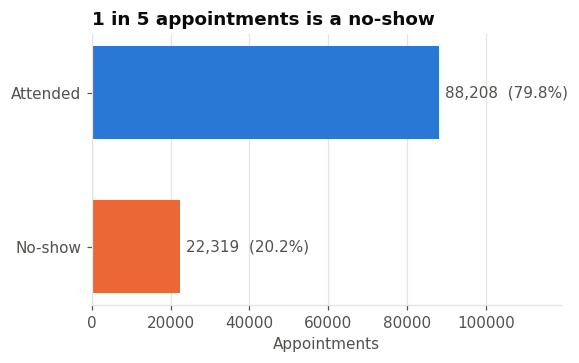

Overall no-show rate: 20.19%


In [6]:
OVERALL = df["no_show"].mean()
counts = df["no_show"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5.5, 3.2))
bars = ax.barh(["Attended", "No-show"], counts.values, color=[BLUE, ORANGE], height=0.6)
ax.bar_label(bars, labels=[f"{c:,}  ({c / len(df):.1%})" for c in counts.values], padding=4, color=INK_2)
ax.set_xlim(0, counts.max() * 1.35); ax.invert_yaxis(); ax.grid(axis="y", visible=False)
ax.set_title("1 in 5 appointments is a no-show"); ax.set_xlabel("Appointments")
save(fig, "01_target_balance"); plt.show()
print(f"Overall no-show rate: {OVERALL:.2%}")

The classes are imbalanced (about 80 / 20). A model that always predicts "attended" would be ~80% accurate while being useless,
so **accuracy is not a suitable metric**; we will use ROC-AUC, PR-AUC, and precision/recall on the no-show class.

## 5. Data quality issues

In [7]:
issues = pd.DataFrame({
    "rows": [
        (df["Age"] < 0).sum(),
        (df["Age"] == 0).sum(),
        (df["Age"] > 100).sum(),
        (df["lead_days"] < 0).sum(),
        (df["Handcap"] > 1).sum(),
        (df["weekday"] == "Saturday").sum(),
        (raw["PatientId"] % 1 != 0).sum(),
    ]
}, index=[
    "Age < 0 (invalid)",
    "Age = 0 (infants, plausible)",
    "Age > 100 (rare, plausible)",
    "Booked after the appointment date (invalid)",
    "Handcap > 1 (a count, not a yes/no flag)",
    "Appointment on a Saturday",
    "PatientId stored as a non-integer float",
])
issues

,rows
Age < 0 (invalid),1
"Age = 0 (infants, plausible)",3539
"Age > 100 (rare, plausible)",7
Booked after the appointment date (invalid),5
"Handcap > 1 (a count, not a yes/no flag)",199
Appointment on a Saturday,39
PatientId stored as a non-integer float,5


In [8]:
print("Handcap values:"); print(df["Handcap"].value_counts().sort_index().to_string())
print("\nRows with negative lead time:")
df.loc[df["lead_days"] < 0, ["ScheduledDay", "AppointmentDay", "lead_days", "No-show"]]

Handcap values:
Handcap
0    108286
1      2042
2       183
3        13
4         3

Rows with negative lead time:


,ScheduledDay,AppointmentDay,lead_days,No-show
27033,2016-05-10T10:51:53Z,2016-05-09T00:00:00Z,-1,Yes
55226,2016-05-18T14:50:41Z,2016-05-17T00:00:00Z,-1,Yes
64175,2016-05-05T13:43:58Z,2016-05-04T00:00:00Z,-1,Yes
71533,2016-05-11T13:49:20Z,2016-05-05T00:00:00Z,-6,Yes
72362,2016-05-04T06:50:57Z,2016-05-03T00:00:00Z,-1,Yes


**Decisions for the pipeline:** drop the `Age < 0` row and the 5 rows booked after the appointment (they cannot occur in real use);
keep ages 0 and 100+; convert `Handcap` to a yes/no flag; read `PatientId` as a string.

## 6. Lead time: the strongest signal

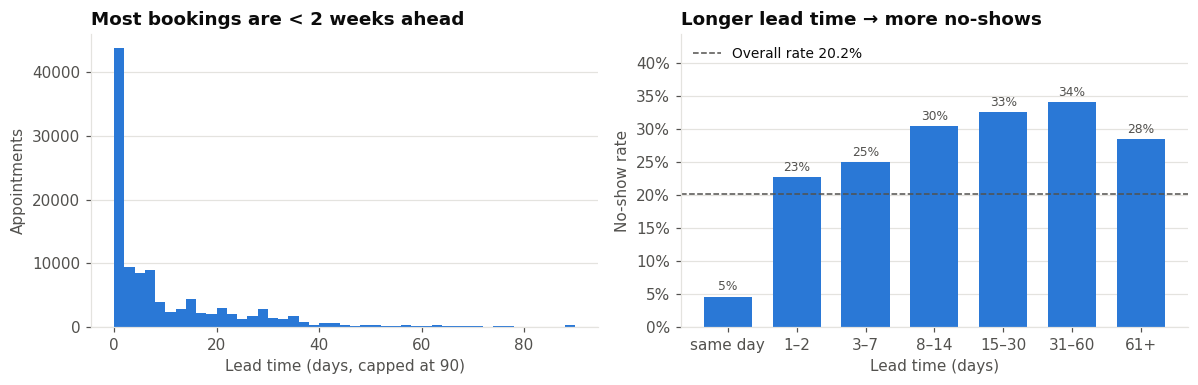

,appointments,no_show_rate
lead_group,,
same day,38563,4.6%
1–2,11938,22.7%
3–7,20247,25.0%
8–14,12025,30.5%
15–30,17371,32.6%
31–60,8283,34.2%
61+,2095,28.4%


In [9]:
LEAD_BINS = [-1, 0, 2, 7, 14, 30, 60, 200]
LEAD_LABELS = ["same day", "1–2", "3–7", "8–14", "15–30", "31–60", "61+"]
valid = df[df["lead_days"] >= 0].copy()
valid["lead_group"] = pd.cut(valid["lead_days"], LEAD_BINS, labels=LEAD_LABELS)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
ax1.hist(valid["lead_days"].clip(upper=90), bins=45, color=BLUE)
ax1.set_title("Most bookings are < 2 weeks ahead")
ax1.set_xlabel("Lead time (days, capped at 90)"); ax1.set_ylabel("Appointments"); ax1.grid(axis="x", visible=False)

lead_rate = valid.groupby("lead_group", observed=True)["no_show"].mean()
rate_bars(ax2, lead_rate, OVERALL, "Longer lead time → more no-shows", "Lead time (days)")
fig.tight_layout(); save(fig, "02_lead_time"); plt.show()

valid.groupby("lead_group", observed=True)["no_show"].agg(appointments="size", no_show_rate="mean").pipe(pct, "no_show_rate")

## 7. SMS reminders: a confounding trap

At first sight, patients who received an SMS miss **more** appointments. That would suggest reminders cause no-shows, which makes no sense.
The explanation is that SMS were only sent when the appointment was booked several days ahead, and long lead times have more no-shows anyway.
Comparing **within the same lead-time group** removes most of that effect.

In [10]:
print("No-show rate by SMS_received (raw):")
print(df.groupby("SMS_received")["no_show"].mean().map("{:.1%}".format).to_string())
print("\nShare of appointments that got an SMS, by lead time:")
print(valid.groupby("lead_group", observed=True)["SMS_received"].mean().map("{:.0%}".format).to_string())

No-show rate by SMS_received (raw):
SMS_received
0    16.7%
1    27.6%

Share of appointments that got an SMS, by lead time:
lead_group
same day     0%
1–2          0%
3–7         57%
8–14        58%
15–30       61%
31–60       61%
61+         64%


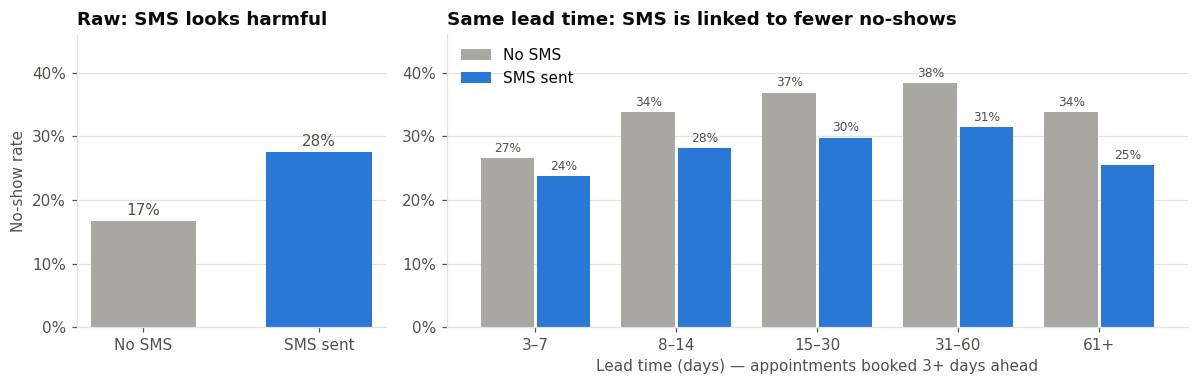

SMS_received,no SMS,SMS sent
lead_group,,
3–7,26.6%,23.8%
8–14,33.8%,28.1%
15–30,36.9%,29.8%
31–60,38.4%,31.5%
61+,33.9%,25.5%


In [11]:
eligible = valid[valid["lead_days"] >= 3]
sms = eligible.groupby(["lead_group", "SMS_received"], observed=True)["no_show"].mean().unstack()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [1, 2.4]})
raw_sms = df.groupby("SMS_received")["no_show"].mean()
b = ax1.bar(["No SMS", "SMS sent"], raw_sms.values, color=[GREY, BLUE], width=0.6)
ax1.bar_label(b, labels=[f"{v:.0%}" for v in raw_sms.values], padding=2, color=INK_2)
ax1.set_title("Raw: SMS looks harmful"); ax1.set_ylabel("No-show rate")
ax1.yaxis.set_major_formatter(PercentFormatter(1, decimals=0)); ax1.grid(axis="x", visible=False)

x = np.arange(len(sms)); w = 0.38
b0 = ax2.bar(x - w / 2 - 0.01, sms[0].values, w, color=GREY, label="No SMS")
b1 = ax2.bar(x + w / 2 + 0.01, sms[1].values, w, color=BLUE, label="SMS sent")
for bb in (b0, b1):
    ax2.bar_label(bb, labels=[f"{v:.0%}" for v in bb.datavalues], padding=2, fontsize=8, color=INK_2)
ax2.set_xticks(x, sms.index.astype(str)); ax2.set_xlabel("Lead time (days) — appointments booked 3+ days ahead")
ax2.set_title("Same lead time: SMS is linked to fewer no-shows"); ax2.legend(loc="upper left")
ax2.yaxis.set_major_formatter(PercentFormatter(1, decimals=0)); ax2.grid(axis="x", visible=False)
ax1.set_ylim(0, max(raw_sms.max(), sms.values.max()) * 1.2); ax2.set_ylim(ax1.get_ylim())
fig.tight_layout(); save(fig, "03_sms_confounding"); plt.show()
sms.rename(columns={0: "no SMS", 1: "SMS sent"}).pipe(pct)

## 8. Patient characteristics

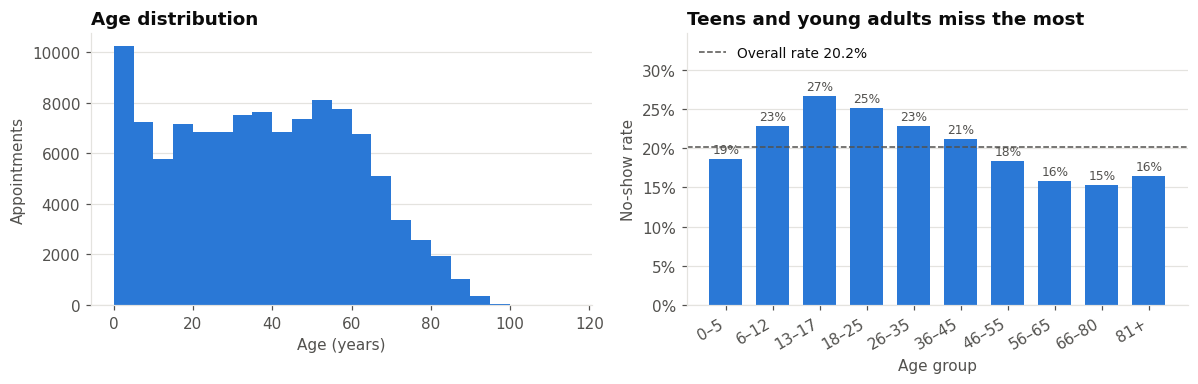

In [12]:
AGE_BINS = [-1, 5, 12, 17, 25, 35, 45, 55, 65, 80, 120]
AGE_LABELS = ["0–5", "6–12", "13–17", "18–25", "26–35", "36–45", "46–55", "56–65", "66–80", "81+"]
valid["age_group"] = pd.cut(valid["Age"], AGE_BINS, labels=AGE_LABELS)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
ax1.hist(valid["Age"], bins=range(0, 116, 5), color=BLUE)
ax1.set_title("Age distribution"); ax1.set_xlabel("Age (years)"); ax1.set_ylabel("Appointments"); ax1.grid(axis="x", visible=False)
rate_bars(ax2, valid.groupby("age_group", observed=True)["no_show"].mean(), OVERALL,
          "Teens and young adults miss the most", "Age group", rotate=30)
fig.tight_layout(); save(fig, "04_age"); plt.show()

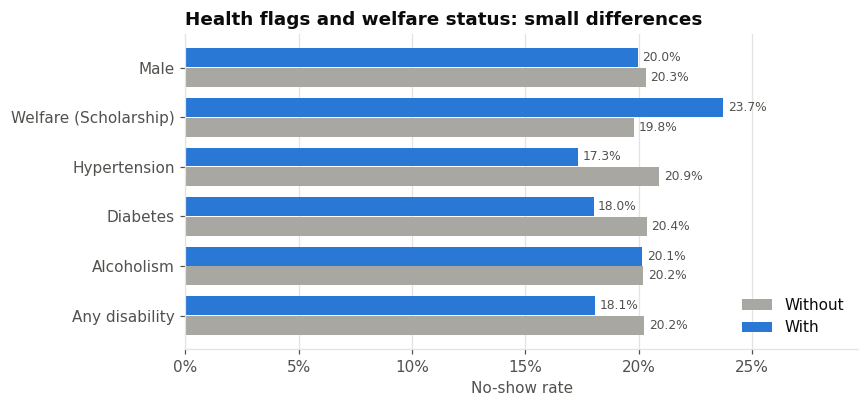

,with,without,share with
feature,,,
Male,20.0%,20.3%,35.0%
Welfare (Scholarship),23.7%,19.8%,9.8%
Hypertension,17.3%,20.9%,19.7%
Diabetes,18.0%,20.4%,7.2%
Alcoholism,20.1%,20.2%,3.0%
Any disability,18.1%,20.2%,2.0%


In [13]:
FLAGS = {"Gender": ("M", "Male"), "Scholarship": (1, "Welfare (Scholarship)"), "Hipertension": (1, "Hypertension"),
         "Diabetes": (1, "Diabetes"), "Alcoholism": (1, "Alcoholism"), "Handcap": (None, "Any disability")}
rows = []
for col, (yes_value, label) in FLAGS.items():
    has = valid[col] >= 1 if yes_value is None else valid[col] == yes_value
    rows.append({"feature": label, "with": valid.loc[has, "no_show"].mean(), "without": valid.loc[~has, "no_show"].mean(),
                 "share with": has.mean()})
flags = pd.DataFrame(rows).set_index("feature")

fig, ax = plt.subplots(figsize=(8, 3.8))
y = np.arange(len(flags)); h = 0.38
b0 = ax.barh(y + h / 2 + 0.01, flags["without"], h, color=GREY, label="Without")
b1 = ax.barh(y - h / 2 - 0.01, flags["with"], h, color=BLUE, label="With")
for bb in (b0, b1):
    ax.bar_label(bb, labels=[f"{v:.1%}" for v in bb.datavalues], padding=3, fontsize=8, color=INK_2)
ax.set_yticks(y, flags.index); ax.invert_yaxis(); ax.grid(axis="y", visible=False)
ax.xaxis.set_major_formatter(PercentFormatter(1, decimals=0)); ax.set_xlim(0, flags[["with", "without"]].values.max() * 1.25)
ax.set_title("Health flags and welfare status: small differences"); ax.set_xlabel("No-show rate"); ax.legend(loc="lower right")
fig.tight_layout(); save(fig, "05_patient_flags"); plt.show()
flags.pipe(pct)

## 9. Appointment context: weekday, neighbourhood, and time

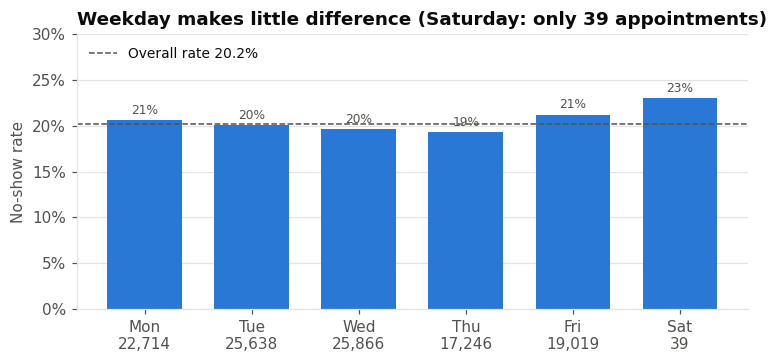

In [14]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
wd = valid.groupby("weekday")["no_show"].agg(["mean", "size"]).reindex(order)

fig, ax = plt.subplots(figsize=(7, 3.4))
rate_bars(ax, wd["mean"], OVERALL, "Weekday makes little difference (Saturday: only 39 appointments)", "")
ax.set_xticks(range(len(wd)), [f"{d[:3]}\n{n:,}" for d, n in zip(wd.index, wd["size"])])
fig.tight_layout(); save(fig, "06_weekday"); plt.show()

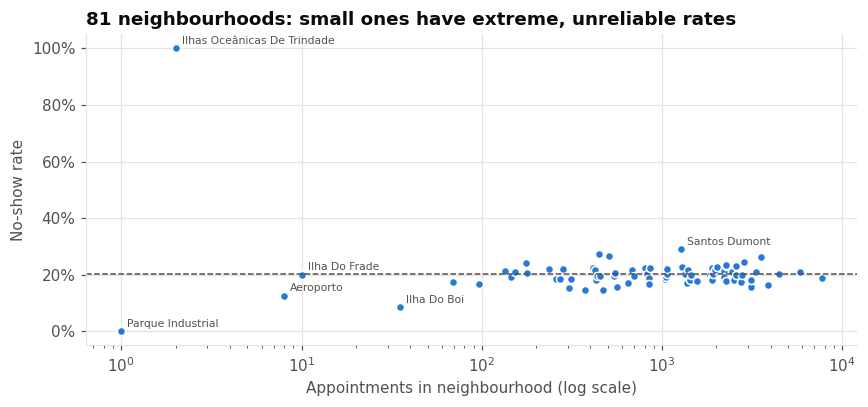

Neighbourhoods with < 50 appointments:
                                 rate  appointments
Neighbourhood                                      
PARQUE INDUSTRIAL            0.000000             1
ILHAS OCEÂNICAS DE TRINDADE  1.000000             2
AEROPORTO                    0.125000             8
ILHA DO FRADE                0.200000            10
ILHA DO BOI                  0.085714            35


In [15]:
nb = valid.groupby("Neighbourhood")["no_show"].agg(rate="mean", appointments="size").sort_values("appointments")

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.scatter(nb["appointments"], nb["rate"], s=28, color=BLUE, edgecolor="white", linewidth=1)
ax.axhline(OVERALL, color=INK_2, lw=1, ls="--")
ax.set_xscale("log"); ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
for name, r in nb[(nb["appointments"] < 50) | (nb["rate"] > 0.28)].iterrows():
    ax.annotate(name.title(), (r["appointments"], r["rate"]), fontsize=7, color=INK_2, xytext=(4, 3), textcoords="offset points")
ax.set_title("81 neighbourhoods: small ones have extreme, unreliable rates")
ax.set_xlabel("Appointments in neighbourhood (log scale)"); ax.set_ylabel("No-show rate")
fig.tight_layout(); save(fig, "07_neighbourhood"); plt.show()
print("Neighbourhoods with < 50 appointments:"); print(nb[nb["appointments"] < 50].to_string())

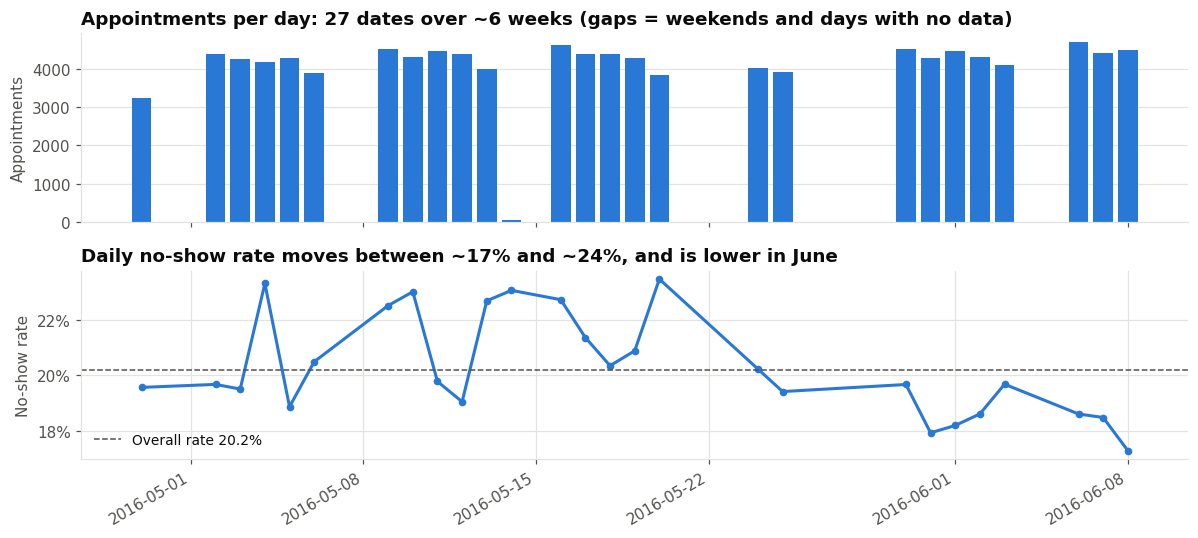

Distinct appointment dates: 27
Daily no-show rate range (days with 100+ appointments): {'min': '17.3%', 'max': '23.5%'}


In [16]:
daily = valid.groupby("appointment_date")["no_show"].agg(rate="mean", appointments="size")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5), sharex=True, gridspec_kw={"height_ratios": [1, 1]})
ax1.bar(daily.index, daily["appointments"], color=BLUE, width=0.8)
ax1.set_title("Appointments per day: 27 dates over ~6 weeks (gaps = weekends and days with no data)"); ax1.set_ylabel("Appointments"); ax1.grid(axis="x", visible=False)
ax2.plot(daily.index, daily["rate"], color=BLUE, lw=2, marker="o", ms=4)
ax2.axhline(OVERALL, color=INK_2, lw=1, ls="--", label=f"Overall rate {OVERALL:.1%}"); ax2.legend(loc="lower left", fontsize=9)
ax2.set_title("Daily no-show rate moves between ~17% and ~24%, and is lower in June"); ax2.set_ylabel("No-show rate")
ax2.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
fig.autofmt_xdate(); fig.tight_layout(); save(fig, "08_timeline"); plt.show()
print("Distinct appointment dates:", daily.shape[0])
print("Daily no-show rate range (days with 100+ appointments):",
      daily.loc[daily["appointments"] >= 100, "rate"].agg(["min", "max"]).map("{:.1%}".format).to_dict())

## 10. Patient history, and how to use it without leakage

Many patients have several appointments, so their **past** attendance should help predict the next one.
But it is easy to leak the future: when an appointment is booked, we only know the outcome of the patient's
appointments that took place **before the booking date**. Below, each appointment gets two history features computed
under exactly that rule:

- `prior_appointments`: the patient's appointments dated before this booking's `ScheduledDay`;
- `prior_no_shows`: how many of those were no-shows.

For comparison, the *leaky* version counts all of the patient's other no-shows, including future ones.

In [17]:
def history_features(frame):
    """For each row, count the patient's appointments (and no-shows) dated strictly before its booking date."""
    out = np.zeros((len(frame), 2), dtype=int)
    frame = frame.reset_index(drop=True)
    for _, idx in frame.groupby("PatientId").indices.items():
        g = frame.iloc[idx]
        order = np.argsort(g["appointment_date"].values, kind="stable")
        appt = g["appointment_date"].values[order]
        cum_ns = np.concatenate([[0], np.cumsum(g["no_show"].values[order])])
        n_prior = np.searchsorted(appt, g["scheduled_date"].values, side="left")
        out[idx, 0] = n_prior
        out[idx, 1] = cum_ns[n_prior]
    return pd.DataFrame(out, columns=["prior_appointments", "prior_no_shows"])

valid = valid.reset_index(drop=True)
valid[["prior_appointments", "prior_no_shows"]] = history_features(valid)
# Leaky version for comparison: every OTHER no-show of the same patient, past or future
valid["leaky_other_no_shows"] = valid.groupby("PatientId")["no_show"].transform("sum") - valid["no_show"]

print("Appointments with any known history:", f"{(valid['prior_appointments'] > 0).mean():.1%}")

Appointments with any known history: 27.9%


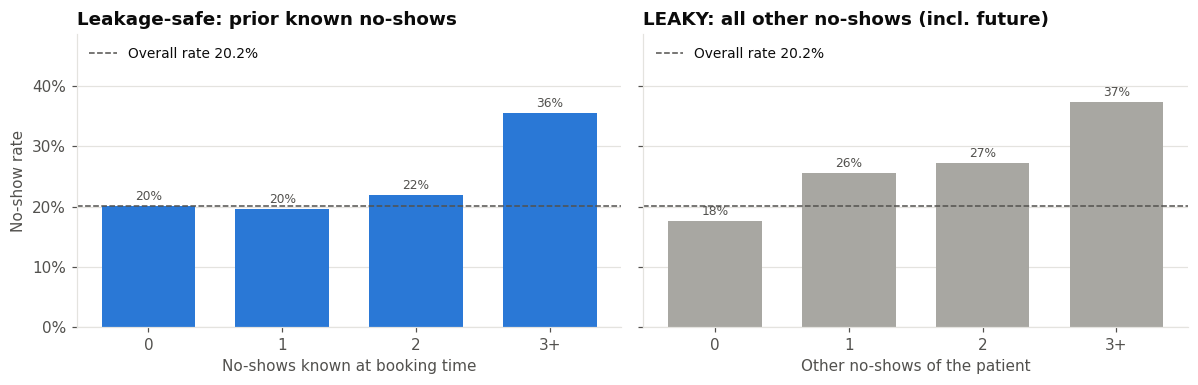

,safe rate,safe count,leaky rate,leaky count
0,20.1%,100609,17.6%,81929
1,19.6%,7369,25.6%,18900
2,22.0%,1636,27.2%,5689
3+,35.6%,908,37.4%,4004


In [18]:
cap = lambda s: s.clip(upper=3).map({0: "0", 1: "1", 2: "2", 3: "3+"})
safe = valid.groupby(cap(valid["prior_no_shows"]))["no_show"].mean()
leaky = valid.groupby(cap(valid["leaky_other_no_shows"]))["no_show"].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
rate_bars(ax1, safe, OVERALL, "Leakage-safe: prior known no-shows", "No-shows known at booking time")
rate_bars(ax2, leaky, OVERALL, "LEAKY: all other no-shows (incl. future)", "Other no-shows of the patient", color=GREY)
ax2.set_ylabel("")
fig.tight_layout(); save(fig, "09_patient_history"); plt.show()

pd.DataFrame({"safe rate": safe.map("{:.1%}".format), "safe count": valid.groupby(cap(valid["prior_no_shows"])).size(),
              "leaky rate": leaky.map("{:.1%}".format), "leaky count": valid.groupby(cap(valid["leaky_other_no_shows"])).size()})

The leaky feature looks more predictive than the safe one (for example, patients with 1 "other" no-show miss 26% of appointments,
against 20% with the safe version), because it partly contains the answer. A model trained on it would look better offline
than it could ever be in real use. **Only the leakage-safe version may be used.**

The safe feature only becomes informative at 3 or more known no-shows, and only 28% of appointments have *any* known history,
because the appointment dates cover just 6 weeks. Patient history will be a modest feature here, not a strong one.

### How strongly is each numeric feature related to no-shows?

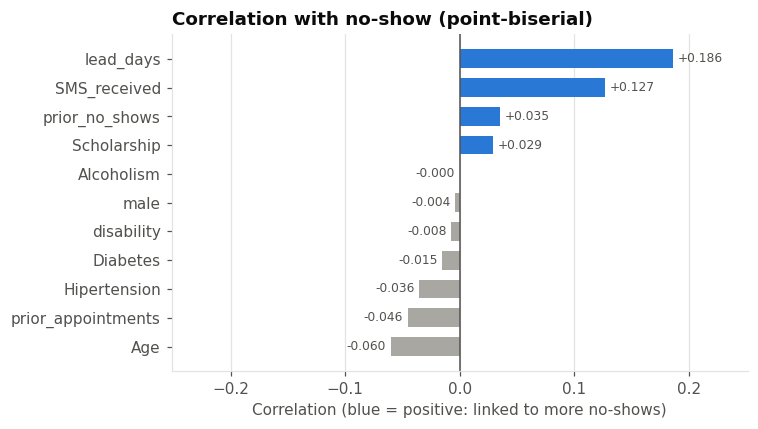

In [19]:
num = valid.assign(male=(valid["Gender"] == "M").astype(int), disability=(valid["Handcap"] > 0).astype(int))
cols = ["lead_days", "SMS_received", "prior_no_shows", "prior_appointments", "Age", "Scholarship",
        "Hipertension", "Diabetes", "Alcoholism", "disability", "male"]
corr = num[cols].corrwith(num["no_show"]).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
b = ax.barh(corr.index, corr.values, color=[BLUE if v > 0 else GREY for v in corr.values], height=0.65)
ax.bar_label(b, labels=[f"{v:+.3f}" for v in corr.values], padding=3, fontsize=8, color=INK_2)
ax.axvline(0, color=INK_2, lw=1); ax.grid(axis="y", visible=False)
lim = np.abs(corr).max() * 1.35; ax.set_xlim(-lim, lim)
ax.set_title("Correlation with no-show (point-biserial)"); ax.set_xlabel("Correlation (blue = positive: linked to more no-shows)")
fig.tight_layout(); save(fig, "10_correlations"); plt.show()

Correlations are weak overall (no single feature separates the classes), so we should expect moderate, not near-perfect,
model performance. Linear correlation also misses non-linear effects like the age pattern above, one reason to try tree-based models.

## 11. Summary: findings and what they mean for the pipeline

| # | Finding | Evidence | Decision |
|---|---|---|---|
| 1 | Target is imbalanced | 20.2% no-shows | Don't use accuracy; use ROC-AUC, PR-AUC, precision/recall; try class weights; tune the decision threshold |
| 2 | Invalid rows exist | 1 row with `Age < 0`; 5 rows booked after the appointment (all labelled no-show) | Drop them in cleaning; reject such inputs at prediction time |
| 3 | `Handcap` is a count (0–4) | 199 rows above 1 | Convert to a yes/no `disability` flag |
| 4 | **Lead time is the strongest signal** | 4.6% no-shows for same-day bookings vs 22.7–34.2% for longer lead times; correlation +0.19 | Key feature: `lead_days`, plus a `same_day` flag |
| 5 | **SMS is confounded with lead time** | Raw: 27.6% (SMS) vs 16.7% (no SMS); within each lead-time group, SMS is linked to **3–8 points fewer** no-shows | Keep SMS only if it is known at prediction time (brief, question 1); never read its raw effect as causal |
| 6 | Age matters, non-linearly | Highest for ages 13–17 (27%), lowest for 66–80 (15%) | Keep `Age`; tree models can capture the curve |
| 7 | Health flags and gender matter little | Every flag moves the rate by less than 4 points; gender by 0.3 points | Keep as features; report fairness by gender and welfare status |
| 8 | Weekday matters little | Mon–Fri between 19% and 21% | Keep as a weak feature |
| 9 | Small neighbourhoods are unreliable | 5 neighbourhoods have fewer than 50 appointments (rates from 0% to 100%) | Group rare ones into "OTHER"; handle unseen neighbourhoods at prediction time |
| 10 | Only ~6 weeks of appointment dates | 27 dates, 2016-04-29 to 2016-06-08; June has a lower daily rate | Chronological split (train → validation → test by appointment date); expect a slightly different base rate in the test period |
| 11 | Patient history can leak | Leaky version inflates rates (e.g. 26% vs 20% for one other no-show) | Build history only from appointments dated before the booking date; covered by an automated test |
| 12 | No single strong feature | All correlations are 0.19 or below | Expect moderate performance (not near-perfect); compare linear and tree-based models |

**Next step (Day 3):** turn these decisions into `src/preprocess.py`, a reusable cleaning, feature, and splitting pipeline shared by training and prediction.